In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

import missingno as msno

from sklearn.model_selection import train_test_split

In [3]:
FILE_PATH = Path.cwd().parent / "datasets" / "animal_data_dirty1.csv"

In [4]:
df = pd.read_csv(FILE_PATH,sep=';') # NOTE : Seperator is ; 

In [5]:
df.head()

,Animal type,Country,Weight kg,Body Length cm,Gender,Animal code,Latitude,Longitude,Animal name,Observation date,Data compiled by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
2,European bison,Poland,930.0,335.0,male,NaN,52.828845,23.820144,Szefu,01.03.2024,Anne Anthony
3,European bison,Poland,909.0,311.0,not determined,NaN,52.830509,23.826849,NaN,01.03.2024,Anne Anthony
4,European bison™,Poland,581.0,277.0,female,NaN,52.834109,23.807093,NaN,01.03.2024,Anne Anthony


In [6]:
def examine_dataframe(df):
    df.columns = [x.lower().strip().replace(" ","_") for x in df.columns]
    print(f"Dataframe shape : {df.shape}")
    print("-"*100)
    print(f"Memory Usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("-"*100)
    print(f"Column Dtypes: \n{df.dtypes.value_counts()}")
    print("-"*100)
    columns_df = pd.DataFrame({
                'column' : df.columns,
                'dtype' : [x for x in df.dtypes],
                '#unique_values' : [df[x].nunique() for x in df.columns],
                '#non_null_values' : df.notna().sum().tolist() ,
                '#null_values' : df.isna().sum().tolist() ,
                '%null_values' : [f'{x:.2f}' for x in ((df.isna().sum()/df.shape[0])*100).to_list()]
                
        })
    return (columns_df)
    


In [7]:
examine_dataframe(df)

Dataframe shape : (1011, 11)
----------------------------------------------------------------------------------------------------
Memory Usage : 0.35 MB
----------------------------------------------------------------------------------------------------
Column Dtypes: 
object     6
float64    5
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


,column,dtype,#unique_values,#non_null_values,#null_values,%null_values
0,animal_type,object,12,991,20,1.98
1,country,object,14,999,12,1.19
2,weight_kg,float64,195,984,27,2.67
3,body_length_cm,float64,112,984,27,2.67
4,gender,object,3,992,19,1.88
5,animal_code,float64,0,0,1011,100.00
6,latitude,float64,735,913,98,9.69
7,longitude,float64,743,913,98,9.69
8,animal_name,object,10,52,959,94.86
9,observation_date,object,114,1011,0,0.00


## The main aim of this notebook is to practice cleaning on the dataset .

In [8]:
# There seems to have a lot of null values in here , we have to move cautiously when dealing with missing values to check whether they are MAR , MCAR or MCNAR.

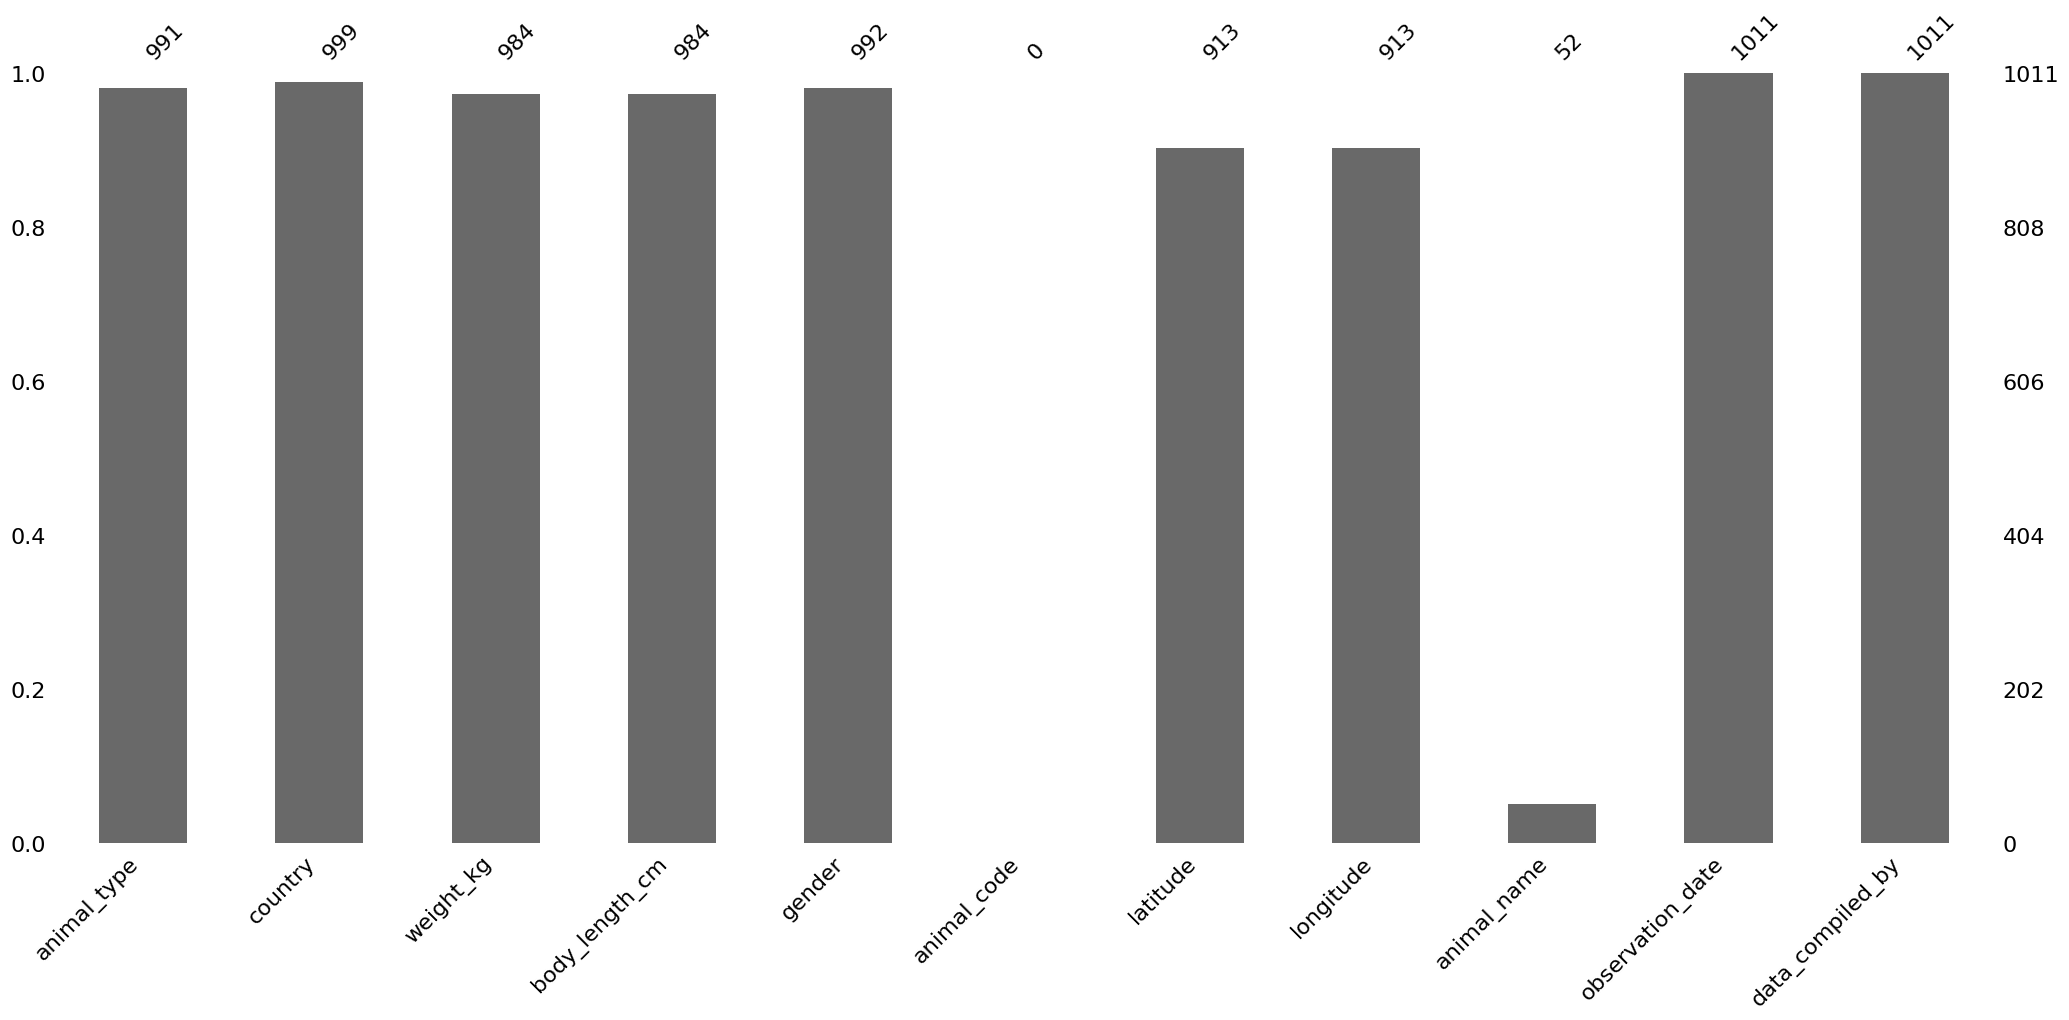

In [9]:
# Let's check whether this missingness is randome or not
msno.bar(df)
plt.show()
# Plot the bar graph which displays us the number of NoN NULL values

### Evaluating NULL values based on Count : 
    Animal code : Completely Missing and cannot be recovered will be forced to drop. 
    Animal name : Again Almost Completely Missing with some 52 values left ( may be dropped ).
>   Rest of the columns shall be handled by various transformations and techniques.

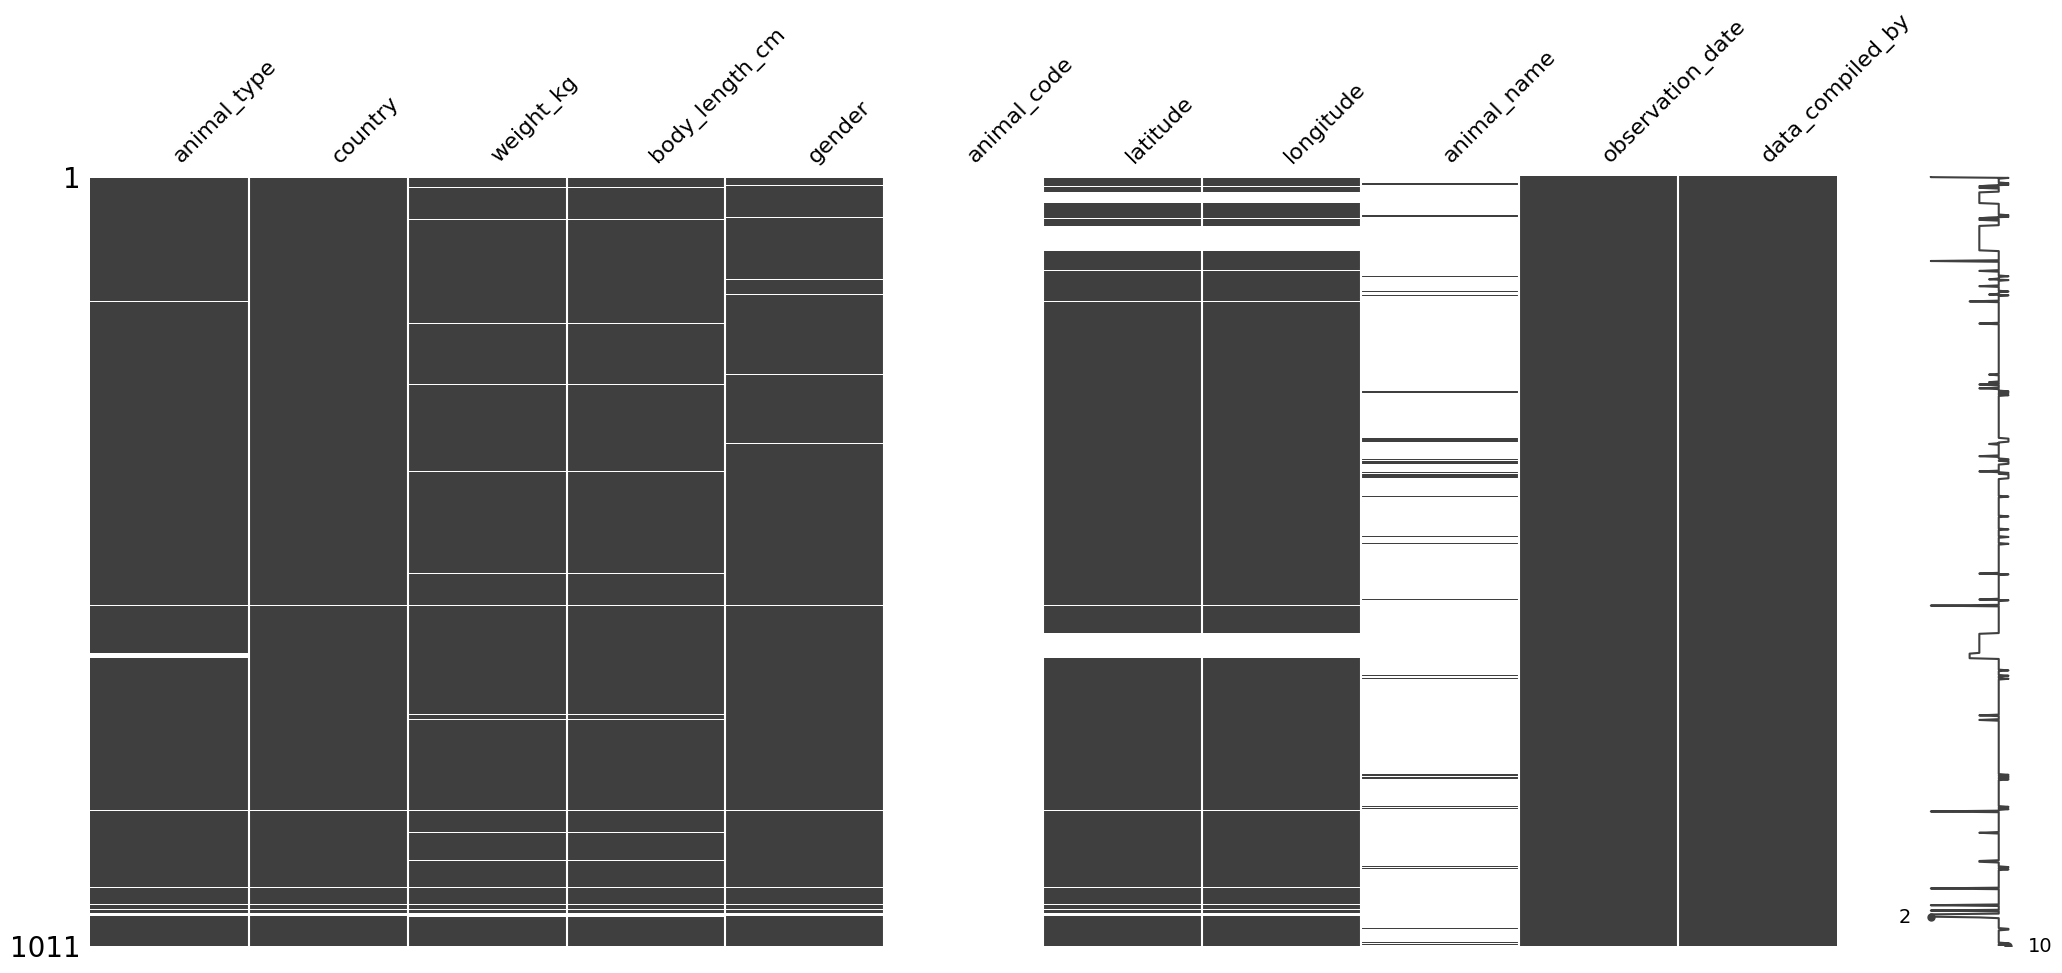

In [10]:
# Now let's actually look for patterns in Null Values by plotting the matrix and then the heatmap.
msno.matrix(df)
plt.show()

### Evaluating the matrix : 
    1. We Clearly see there are some specific lines in the matrix that rows with completely missing values ( the long spikes seen in the chart at right).
       These values are missing with a pattern suggesting something ( need to be investigated).
    2. The pairs : (Weight kg , Body Length cm) and (Latitude , Longitude) both have missing values together (correlated).
    3. Animal type and gender have some missing values independently with no pattern.
    4. Animal Code is completely missng and in Animal name we barely have any values. 

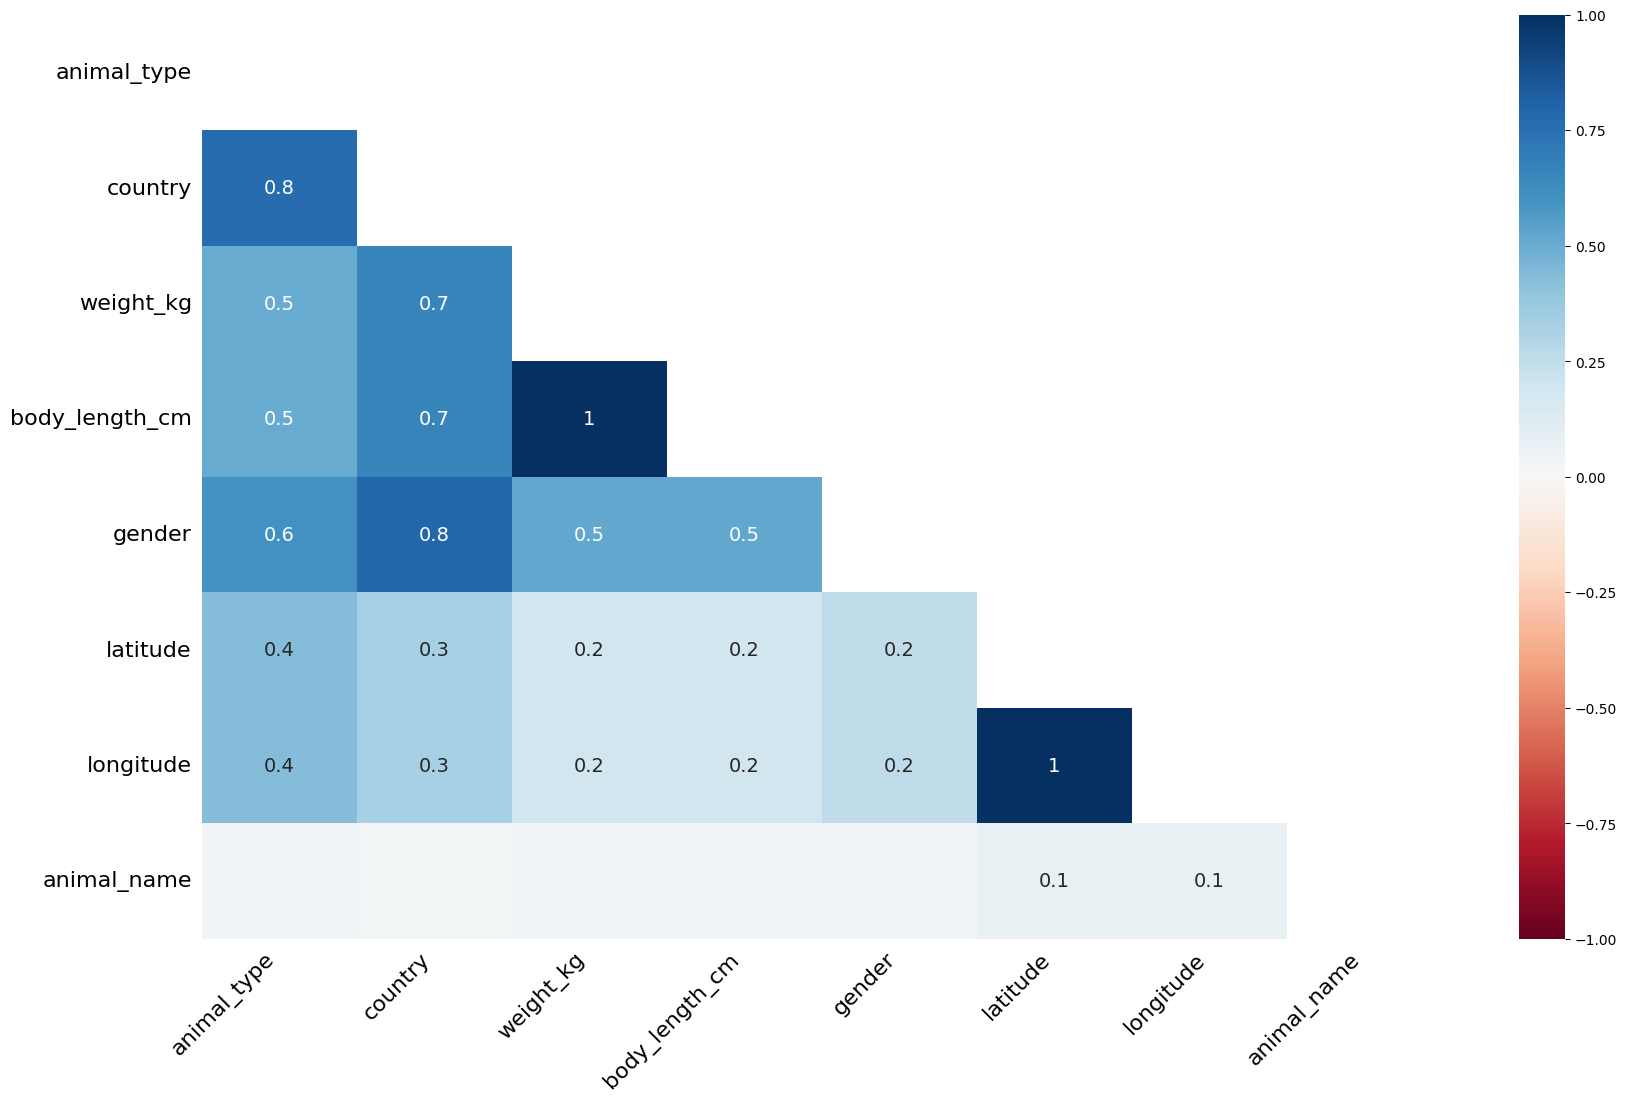

In [11]:
msno.heatmap(df)
plt.show()

In [12]:
# As suspected there is complete correlation between the pairs we discussed .
# One from each pair must be removed before model training as the other column in the pair is redundant and will cause MultiCollinearity in Linear MODELs.

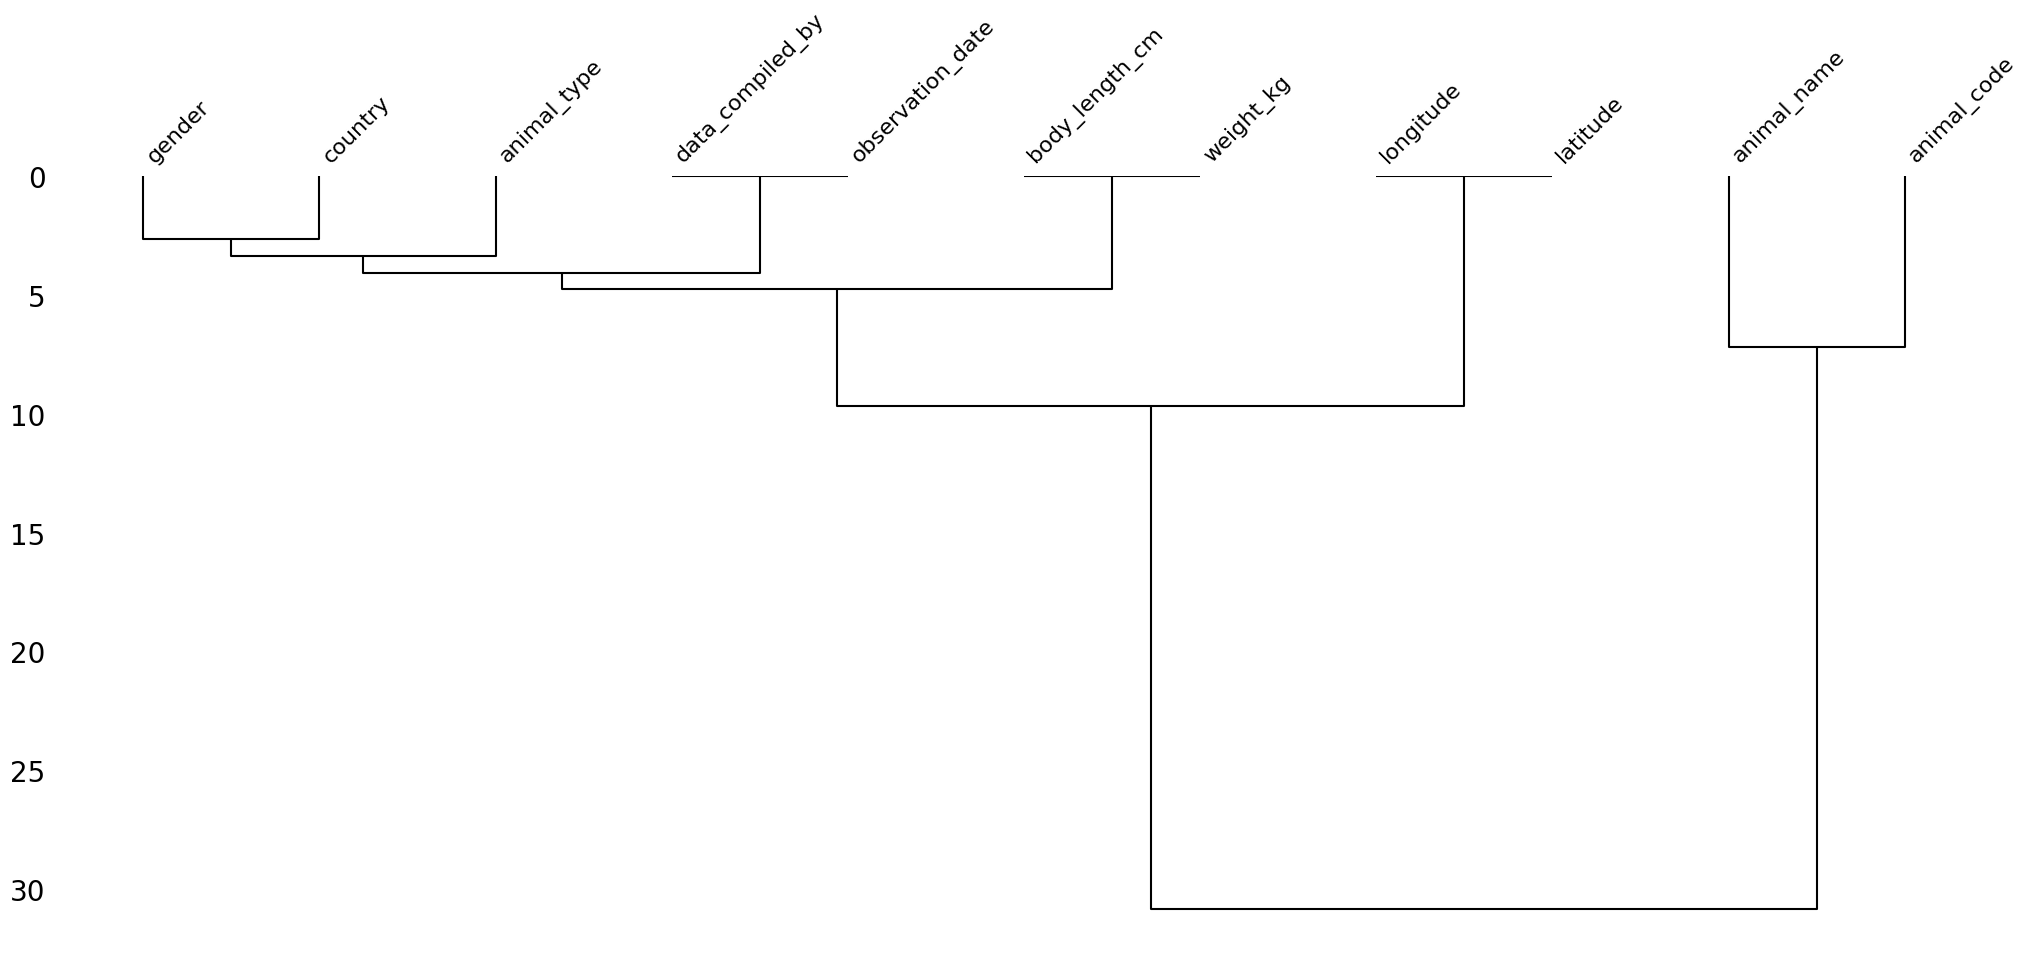

In [13]:
msno.dendrogram(df)
plt.show()

In [14]:
# Before Moving forward i Will remove the Completely missing columns
df = df.drop(columns=['animal_code','animal_name'])

In [15]:
# Now let's one by one analyze the complete dataframe where we have columns missing with a pattern

In [16]:
#CASE 1 : All values are missing completely uptil latitude
val_missing_completely_cols = ['animal_type', 'country', 'weight_kg', 'body_length_cm', 'gender','latitude', 'longitude']
df[df[val_missing_completely_cols].isna().all(axis=1)]
# These are the columns where we had values misisng compleletely 
# If you look closely these values are missing on a specific sequential order of date and is compiled by James Johnson
# We will drop this rows as there is really no way to fix these cols tbh

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.03.2024,James Johnson
563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.04.2024,James Johnson
833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.05.2024,James Johnson
934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.06.2024,James Johnson
956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.07.2024,James Johnson
963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.08.2024,James Johnson
968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.13.2024,James Johnson
969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.14.2024,James Johnson


In [17]:
# A total of 12 rows missing from James Johnson 
# This data is not a normal dataset but a log of Time-Series Analysis by different people overtime

In [18]:
# CASE 2 : Data missing in pairs
pair_1 = ['longitude','latitude']
pair_2 = ['weight_kg','body_length_cm']

In [19]:
df[df[pair_1].isna().all(axis=1)].head() # A total of 98 rows missing from different people

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
13,red squirrel,Poland,0.333,21.0,male,NaN,NaN,01.03.2024,Anne Anthony
21,red squirrel,Germany,0.294,19.0,male,NaN,NaN,01.03.2024,Bob Bobson
22,red squirrel,Germany,0.250,19.0,female,NaN,NaN,01.03.2024,Bob Bobson


In [20]:
df[df[pair_2].isna().all(axis=1)].head() # Total of 27 rows missing in total

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
15,red squirrel,Poland,NaN,NaN,male,52.241177,21.052873,01.03.2024,Anne Anthony
57,red squirrel,Poland,NaN,NaN,male,52.241177,21.052873,01.03.2024,Anne Anthony
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.03.2024,James Johnson


In [21]:
# CASE 3 : Column missing values without a pattern

In [22]:
df[df['animal_type'].isna()].head()

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.03.2024,James Johnson
164,NaN,Austria,0.263,22.0,male,NaN,NaN,05.03.2024,Bob Bobson
563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.04.2024,James Johnson


In [23]:
# Total of 20 rows missing and suprisingly these rows are missing along with (longitude,latitude) and is a subset of there missing rows.

In [24]:
df[df['gender'].isna()].head()

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
12,red squirrel,Poland,0.34,21.0,NaN,52.240284,21.051948,01.03.2024,Anne Anthony
54,red squirrel,Poland,0.34,21.0,NaN,52.240284,21.051948,01.03.2024,Anne Anthony
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.03.2024,James Johnson


In [25]:
# Total of 19 rows missing without having a any pattern with any other columm's missingness (maybe MCAR)

In [26]:
# I am trying to use the observation_date as a strategy for filling values (using ffill or bfill)
# Actually we need to clean the observation_date column beforehand to make sure that our filling is successfull
# After inspection I found that the observation_date col is mixed with different datetime formats and we just can;t use to datetime on them
# We need to inspect more about the column.

In [27]:
# Inspection on observation_date
df['observation_date'].head(10) # The values are strictly increasing BUT LATER found to have mixed values after further investigation.

0    03.01.2024
1    03.02.2024
2    01.03.2024
3    01.03.2024
4    01.03.2024
5    01.03.2024
6    01.03.2024
7    01.03.2024
8    01.03.2024
9    01.03.2024
Name: observation_date, dtype: object

In [28]:
# Now we need to figure out the number of unique types present in this column and their fix ---> datetime object
df['observation_date'].str.replace(r'[a-zA-Z]', 'A', regex=True).str.replace(r'\d', 'X', regex=True)

0       XX.XX.XXXX
1       XX.XX.XXXX
2       XX.XX.XXXX
3       XX.XX.XXXX
4       XX.XX.XXXX
           ...    
1006    X AAA XXXX
1007    X AAA XXXX
1008    X AAA XXXX
1009    X AAA XXXX
1010    X AAA XXXX
Name: observation_date, Length: 1011, dtype: object

In [29]:
(df['observation_date'].str.replace(r'[a-zA-Z]', 'A', regex=True).str.replace(r'\d', 'X', regex=True)).value_counts()
# Basically this was my custom filter to check for number of unique datetime patterns present in the datetime 
# It turns there are only two patterns which are as below 
# The X is a number and A is a alphabet 
# Fortunately both of this patterns can be handled by to_datetime method

observation_date
XX.XX.XXXX    972
X AAA XXXX     39
Name: count, dtype: int64

In [30]:
df['observation_date'] = pd.to_datetime(df['observation_date'], format='mixed', dayfirst=True,errors='coerce')

In [31]:
df['observation_date'].info() # Now a datetime object

<class 'pandas.core.series.Series'>
RangeIndex: 1011 entries, 0 to 1010
Series name: observation_date
Non-Null Count  Dtype         
--------------  -----         
1011 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 8.0 KB


In [32]:
# Check to know whether datetime column was sorted or not
df['observation_date'].is_monotonic_increasing,df['observation_date'].is_monotonic_decreasing
# The values seem to be nor increasing or decreasing in a go , indicating that the values are not sorted and originally not sorted

(False, False)

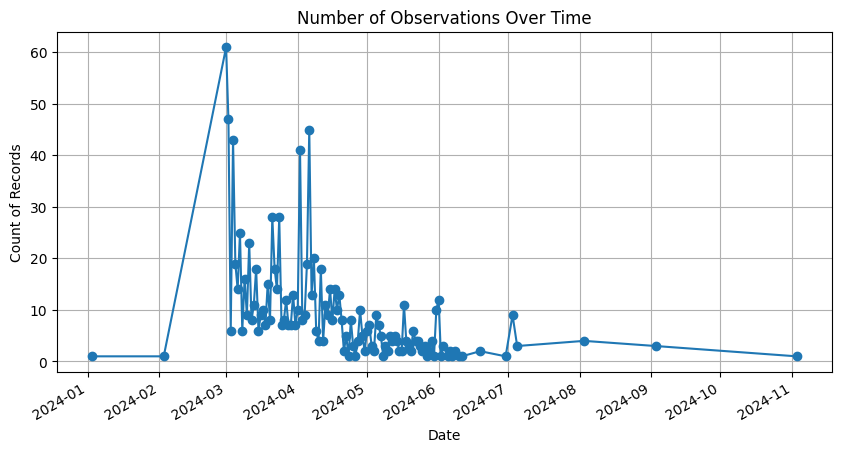

In [33]:
### Count according to each day
 
# 1. Count how many times each unique date appears
date_counts = df['observation_date'].value_counts()

# 2. Sort chronologically by the dates (the index of date_counts)
date_counts = date_counts.sort_index()

# 3. Plot the counts over time
date_counts.plot(kind='line', marker='o', figsize=(10, 5))

plt.title('Number of Observations Over Time')
plt.xlabel('Date')
plt.ylabel('Count of Records')
plt.grid(True)
plt.show()

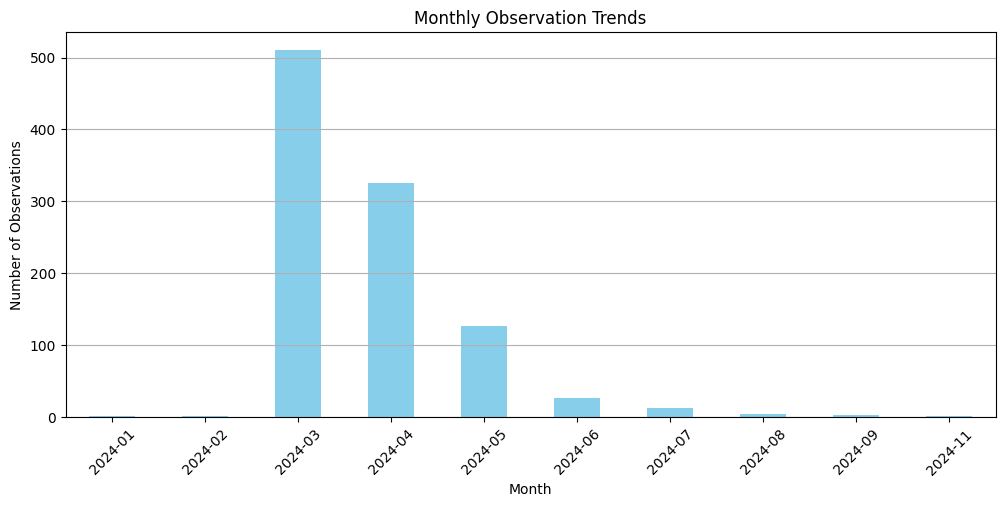

In [34]:
### Count according to each month

# Group by year-month and count the records
monthly_counts = df.groupby(df['observation_date'].dt.to_period('M')).size()

# Plot as a bar chart to easily see monthly volume
monthly_counts.plot(kind='bar', figsize=(12, 5), color='skyblue')

plt.title('Monthly Observation Trends')
plt.xlabel('Month')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


In [35]:
# Now we wll use actually rearrange the complete dataset using observation_time.
df.sort_values(by='observation_date').index.is_monotonic_increasing # This test again show that the date were originally not ordered.

False

In [36]:
# Rearrange the entire DataFrame chronologically
df = df.sort_values(by='observation_date').reset_index(drop=True)

In [37]:
df.head()

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-03,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-03,James Johnson
2,red squirrel,Germany,0.289,19.0,female,NaN,NaN,2024-03-01,Bob Bobson
3,red squirrel,Germany,0.308,22.0,male,NaN,NaN,2024-03-01,Bob Bobson
4,European bison,Slovakia,420.000,182.0,male,49.054684,22.417189,2024-03-01,John Johnson


In [38]:
# The filling wont be done globally but done according to different cases and groups we explored before .

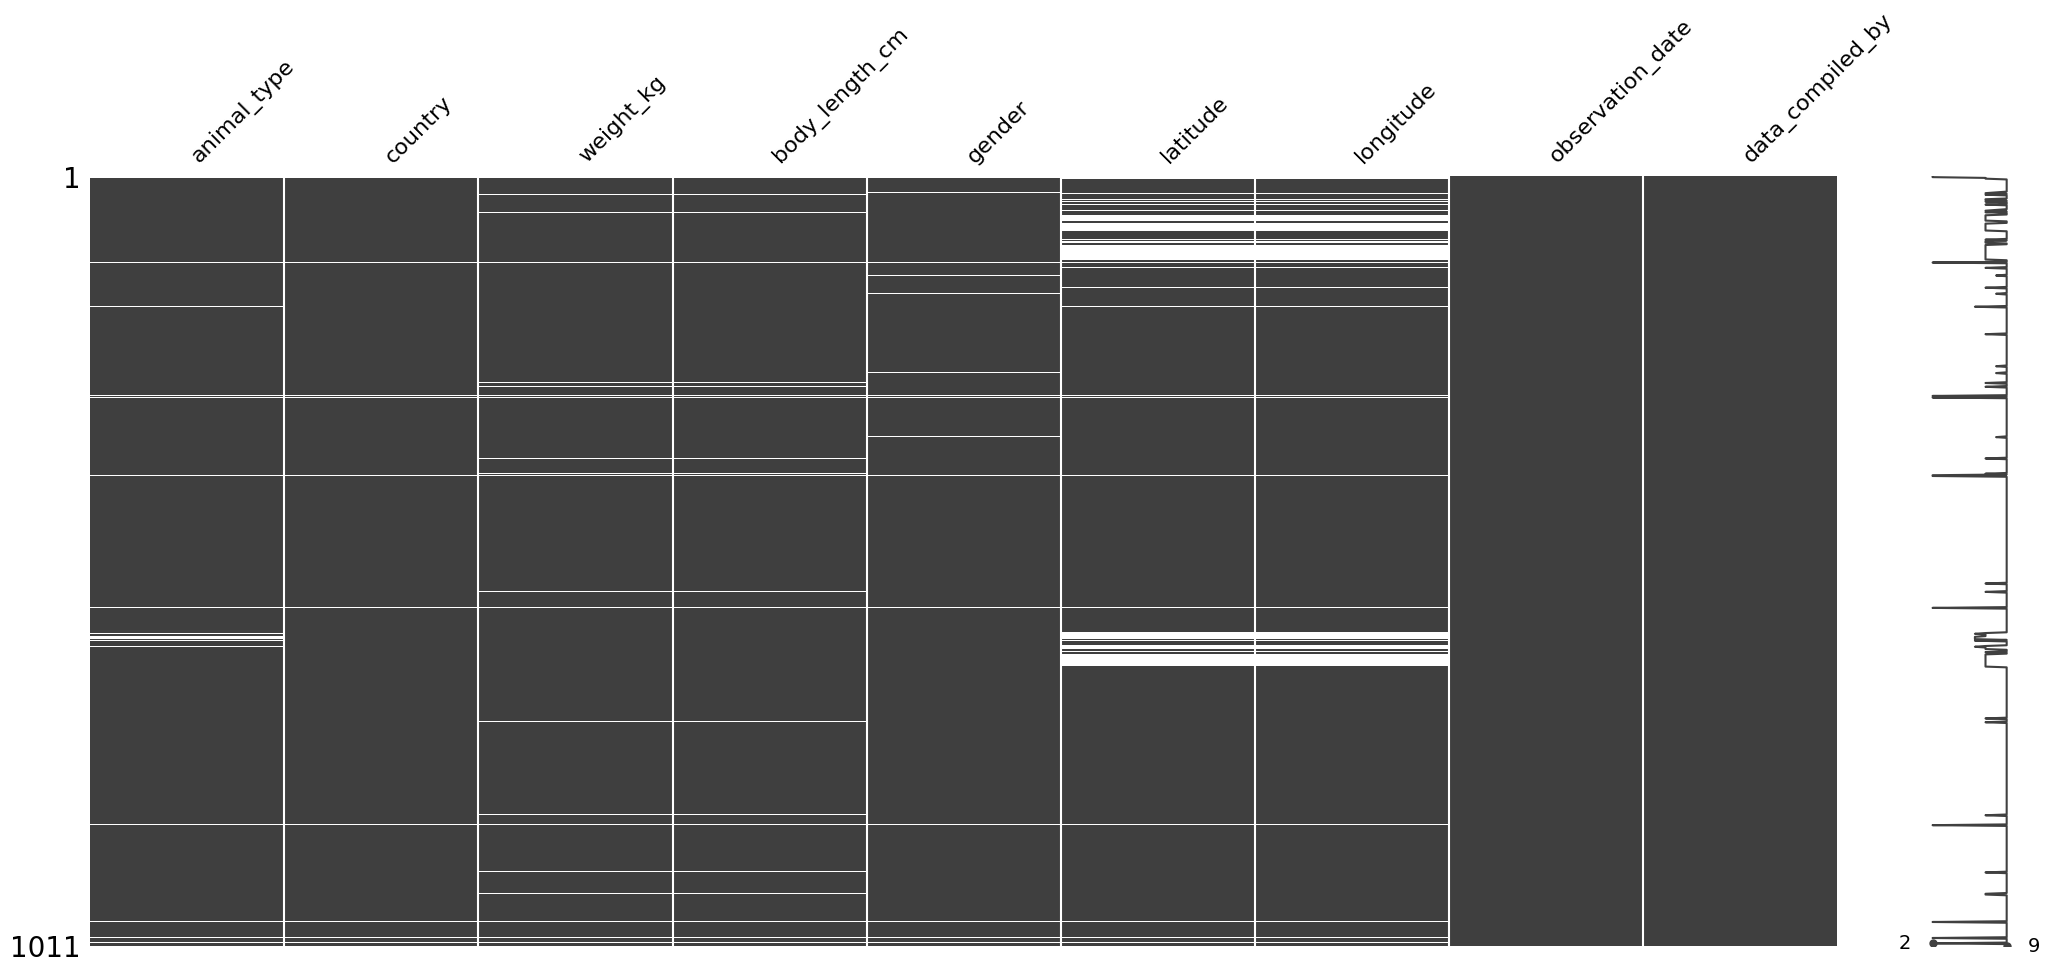

In [39]:
# Now again I would like to peek at the missingness now
msno.matrix(df)
plt.show()

In [40]:
# Still there seems to have the same pattern as we had previously when the dates were not ordered.

In [41]:
# Filling CASE 1 : Where James Johnson failed or deliberately did not fill the values
# There is a distinctive pattern here : Not filling all the values means one thing that is he either did not go out to the fiels to log data.
# Or maybe he went out and did not found an animal to write it down and these are deliberate data itself.

# I will decide to fill each row here with a placeholder no observed data
# We will fill the columns : 
#   categorical  : 'No Sighting'
#   numeric      : 0

In [42]:
# 1. Define the columns that should be entirely blank
val_missing_completely_cols # We already have this 

# 2. Create a mask where ALL of these columns are null in a row
all_missing_mask = df[val_missing_completely_cols].isna().all(axis=1)

# 3. Apply your placeholder logic safely ONLY to those rows
categorical_cols = ['animal_type', 'gender','country']
df.loc[all_missing_mask, categorical_cols] = df.loc[all_missing_mask, categorical_cols].fillna('No Sighting')

numerical_cols = ['weight_kg', 'body_length_cm','latitude','longitude']
df.loc[all_missing_mask, numerical_cols] = df.loc[all_missing_mask, numerical_cols].fillna(0)

# 4. Verify the changes
df[df['animal_type'] == 'No Sighting']

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-01-03,James Johnson
1,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-02-03,James Johnson
113,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-03-03,James Johnson
288,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-03-13,James Johnson
290,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-03-14,James Johnson
392,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-03-22,James Johnson
393,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-03-22,James Johnson
566,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-04-03,James Johnson
851,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-05-03,James Johnson
978,No Sighting,No Sighting,0.0,0.0,No Sighting,0.0,0.0,2024-06-03,James Johnson


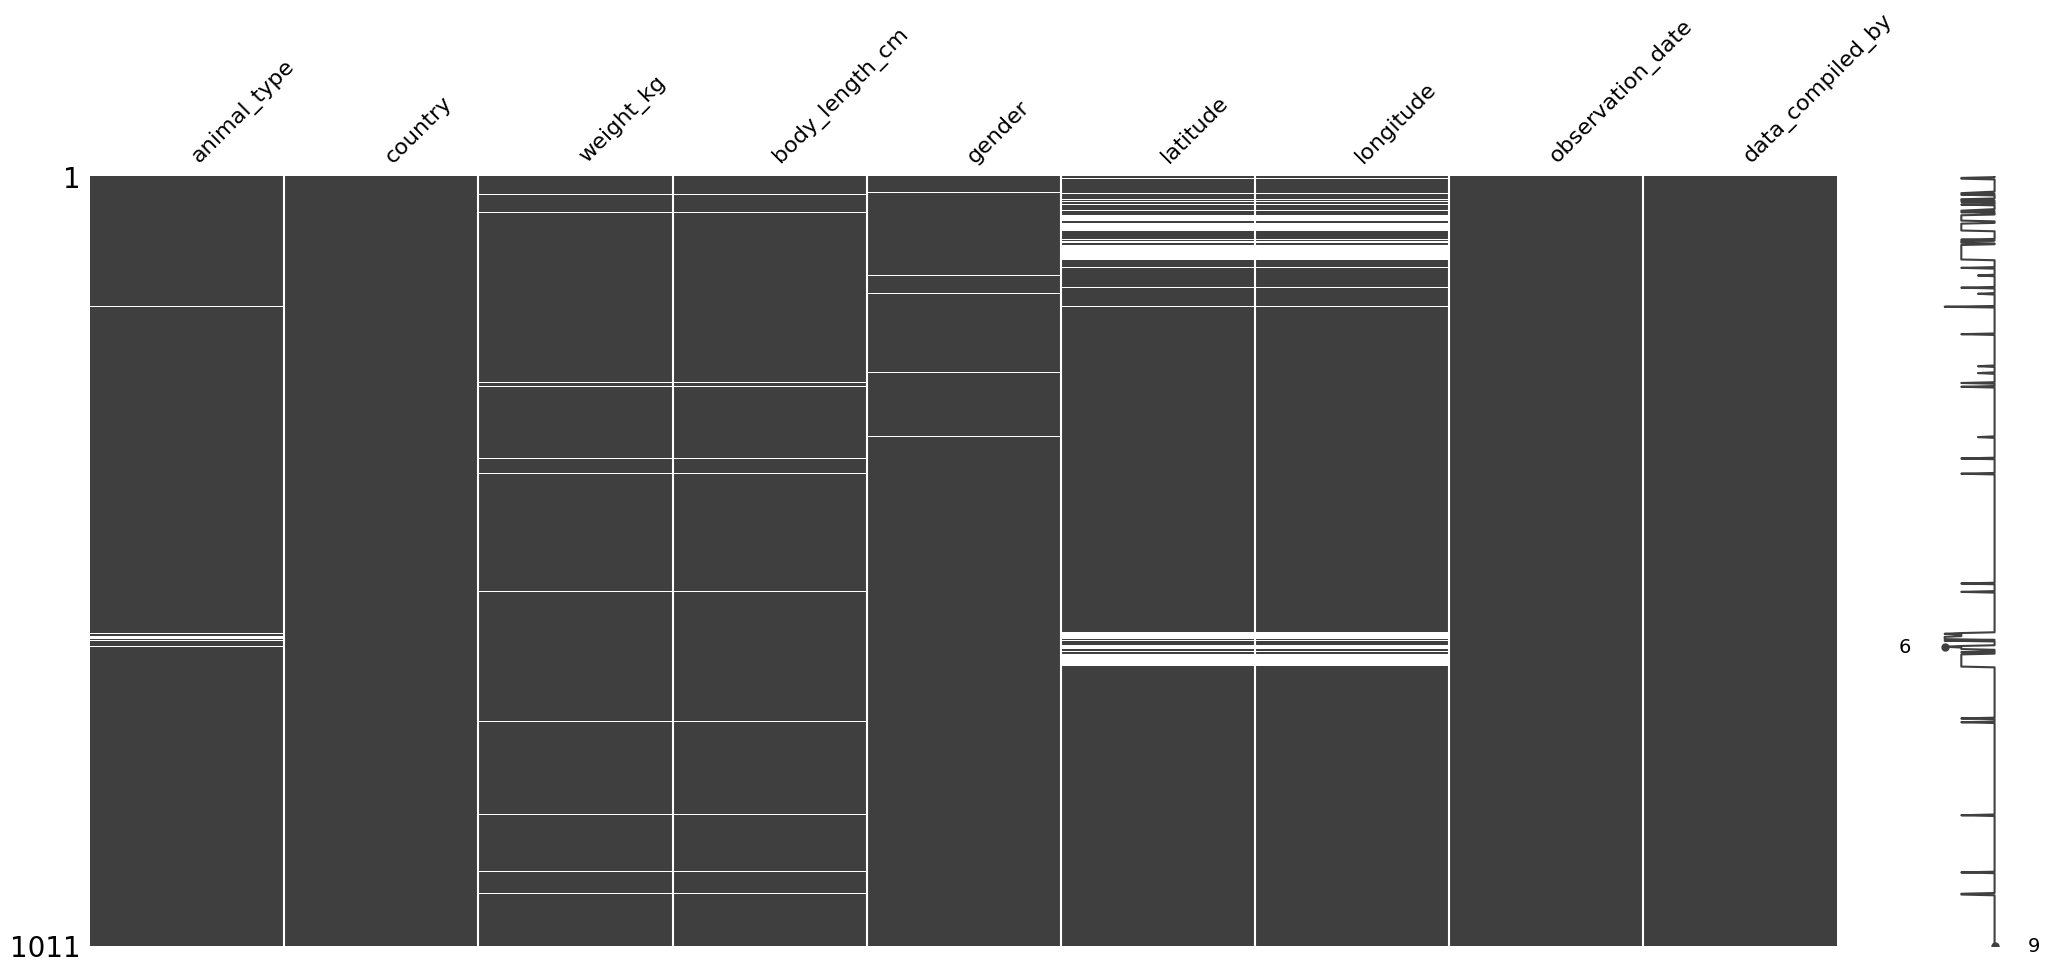

In [43]:
# If we rerun the msno.matrix() --->  The country column was also automatically handled.an
# Now again I would like to peek at the missingness now
msno.matrix(df)
plt.show()

In [44]:
# Now we handle CASE 3 directly that is we filol animal_type and gender with a placeholder Unknown here for now
# Fill accidental missing text columns with an explicit category
df['animal_type'] = df['animal_type'].fillna('Unknown Species')
df['gender'] = df['gender'].fillna('Unknown Gender')

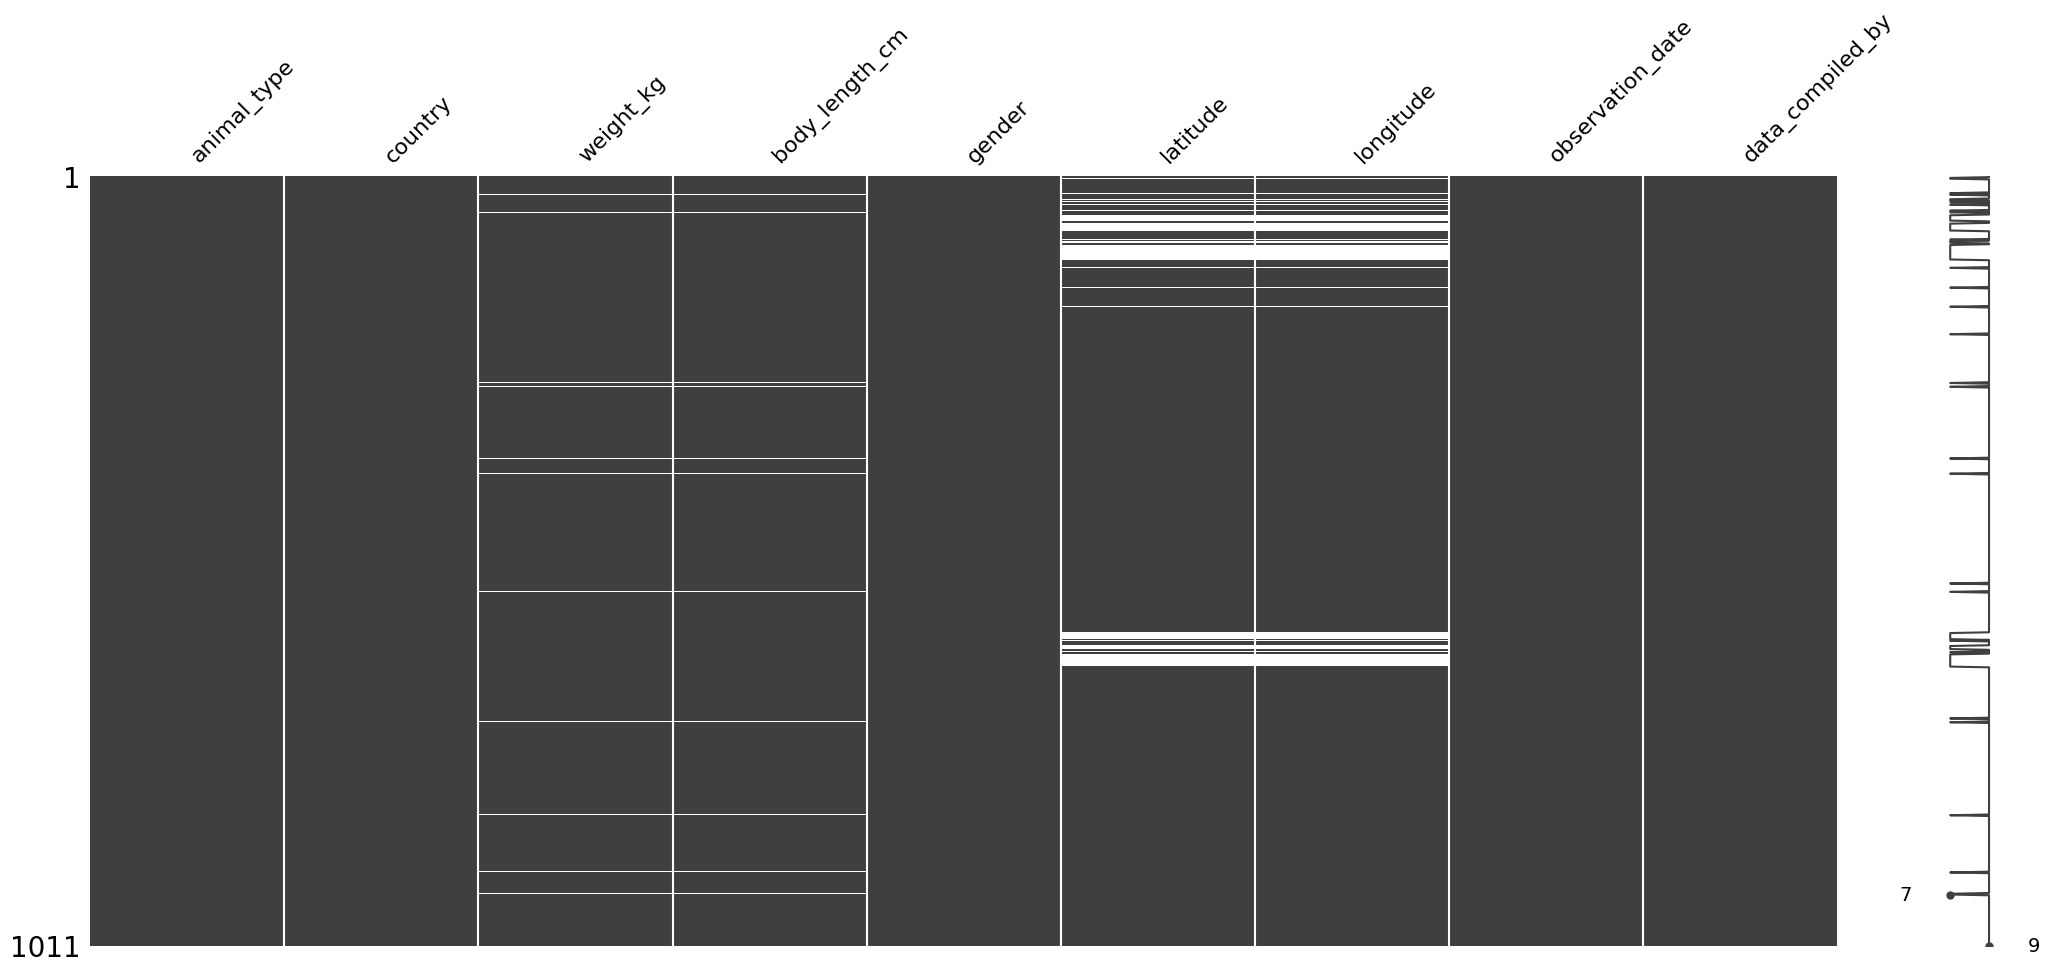

In [45]:
msno.matrix(df)
plt.show()

In [55]:
# CASE 2 : Filling the pair now on animal_type and gender
# Why now cause we cannot use a column with missing value to fill by grouping upon an animal's animal_type and gender.
# Now we will use groupby operation to fill these numeric column responsibly

# Group by your clean categories and fill numeric metrics
df['weight_kg'] = df.groupby(['animal_type', 'gender'])['weight_kg'].transform(lambda x: x.fillna(x.median()))
df['body_length_cm'] = df.groupby(['animal_type', 'gender'])['body_length_cm'].transform(lambda x: x.fillna(x.median()))


# Fill missing coordinates with the country's median location
df['latitude'] = df.groupby('country')['latitude'].transform(lambda x: x.fillna(x.median()))
df['longitude'] = df.groupby('country')['longitude'].transform(lambda x: x.fillna(x.median()))

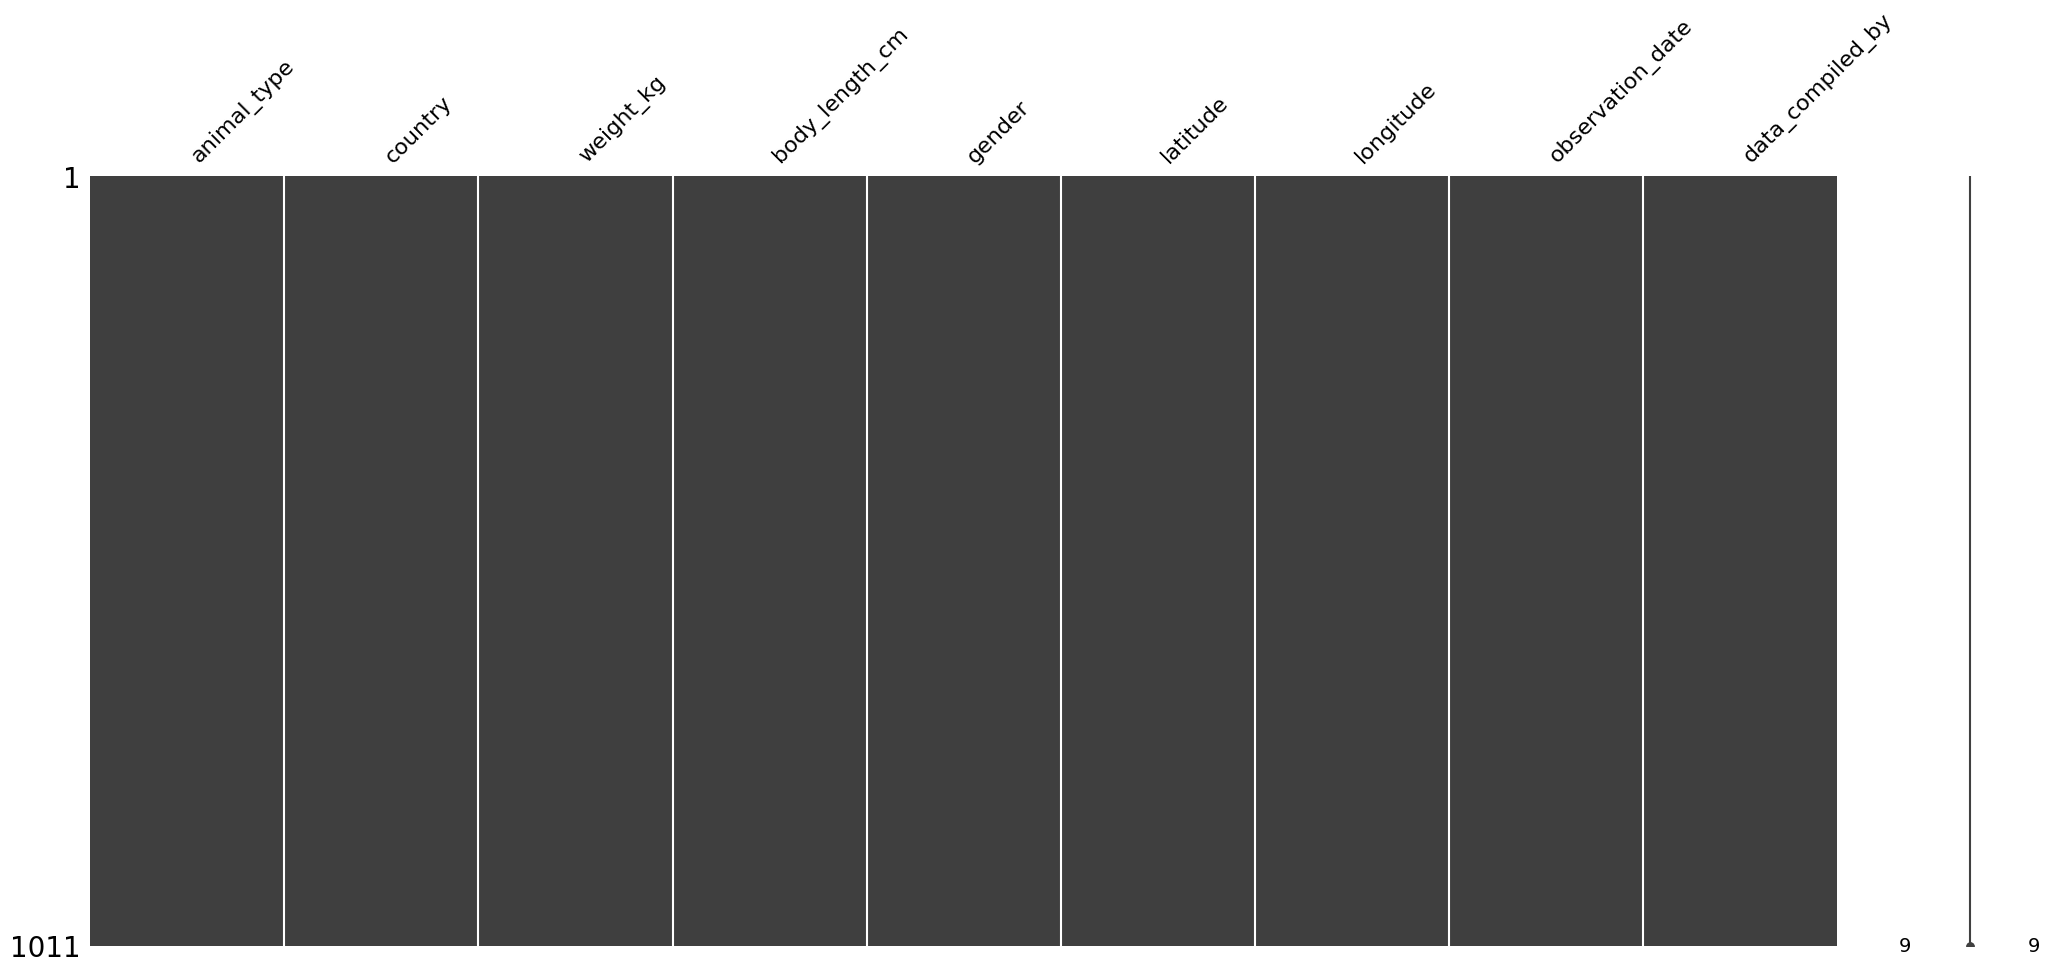

In [56]:
msno.matrix(df)
plt.show()

In [57]:
# Everything cleaned now 